# **🧪LAB  : Deep Dive into TinyML**


###  **Introduction to TinyML & Edge AI**
TinyML (Tiny Machine Learning) is about running machine learning models on small, low-power devices like microcontrollers and IoT sensors. Unlike traditional ML, which requires powerful servers, TinyML enables real-time decision-making on edge devices.



🔥 What We Can Do in Google Colab:

✅ Train lightweight ML models using TensorFlow Lite.

✅ Convert models to TFLite format for edge deployment.

✅ Simulate Edge AI inference on Colab (instead of running it on a real device).

✅ Use Edge Impulse Studio (web-based) to train models & export them to TinyML devices.

❌ What We CANNOT Do in Google Colab:

🚫 Deploy models on real microcontrollers (since Colab has no direct hardware access).

🚫 Test real-time sensor data processing (e.g., live data from an accelerometer or temperature sensor).

To run models on actual hardware, we need Arduino Nano 33 BLE Sense, Raspberry Pi, or ESP32, which Google Colab does not support directly.

#### 🔥 **Setting Up the Environment**
We'll use Google Colab for this lab. Run the following to install required libraries:



In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

####  **Example 1: Gesture Detection using Accelerometer Data**

Wearable IoT devices use accelerometer data for detecting activities like walking, running, or jumping. We'll build a simple model to classify hand gestures.


**🔹 Step 1: Generate Sample Accelerometer Data**

In [ ]:
# Simulating 3 types of hand gestures: wave, shake, and tap
gesture_data = {
    "wave": np.random.normal(0, 1, (100, 3)),
    "shake": np.random.normal(3, 1, (100, 3)),
    "tap": np.random.normal(-3, 1, (100, 3))
}

# Combine and create labels
data = np.vstack([gesture_data["wave"], gesture_data["shake"], gesture_data["tap"]])
labels = np.array([0]*100 + [1]*100 + [2]*100)  # 0=Wave, 1=Shake, 2=Tap

**🔹 Step 2: Build a Simple Neural Network**

In [ ]:
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(3,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**🔹 Step 3: Train and Convert to TensorFlow Lite**

In [ ]:
model.fit(data, labels, epochs=20, batch_size=10, verbose=1)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1119 - loss: 1.2305    
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4682 - loss: 0.8321 
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6767 - loss: 0.6483
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7127 - loss: 0.5903
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7788 - loss: 0.4898
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7994 - loss: 0.4424
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7888 - loss: 0.4473 
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8386 - loss: 0.3964 
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8529 - loss: 0.4128
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8816 - loss: 0.3438
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8955 - loss: 0.3522 
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9

#### **Example 2: Keyword Spotting (Basic Speech Recognition)**

IoT devices like Alexa use speech recognition to detect commands. We'll build a model to classify simple words.


**🔹 Step 1: Load Speech Data**

import required library

**🔹 Step 2: Preprocess & Train**

In [ ]:
def preprocess_audio(audio, label):
    audio = tf.reshape(audio, [-1])
    return audio, label

speech_data = speech_data.map(preprocess_audio).batch(32)

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(16000,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(speech_data, epochs=10)

**🔹 Step 3: Convert & Test in TFLite**

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

#### **Example 3 Anomaly Detection in IoT Sensors**

Goal: Detect unusual sensor readings (e.g., temperature spikes) using an autoencoder-based approach in TinyML.

Step 1: Simulate IoT Sensor Data
We generate a dataset with normal temperature readings and introduce anomalies.

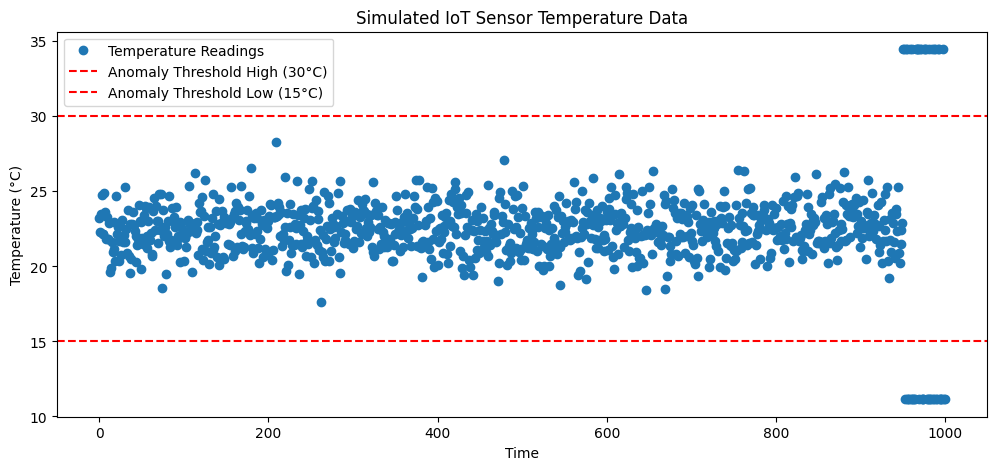

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate normal temperature readings (20°C to 25°C)
normal_temps = np.random.normal(loc=22.5, scale=1.5, size=950)

# Introduce some anomalies (spikes above 30°C or drops below 15°C)
anomalies = np.random.choice([np.random.uniform(30, 35), np.random.uniform(10, 15)], size=50)

# Combine data
temperatures = np.concatenate([normal_temps, anomalies])

# Create DataFrame
df = pd.DataFrame({"Temperature": temperatures})

# Plot the data
plt.figure(figsize=(12, 5))
plt.plot(df["Temperature"], label="Temperature Readings", marker='o', linestyle='')
plt.axhline(y=30, color='r', linestyle='--', label="Anomaly Threshold High (30°C)")
plt.axhline(y=15, color='r', linestyle='--', label="Anomaly Threshold Low (15°C)")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Simulated IoT Sensor Temperature Data")
plt.show()


Step 2: Train an Autoencoder Model

We use an autoencoder neural network to learn normal patterns and detect anomalies.

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0044
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0038
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0041
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0037
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0040
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0038
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035
Epoch 10/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0038
Epoch 11/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0038
Epoch 12/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0040
Epoch 13/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0037
Epoch 14/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0040
Epoch 15/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039
Epoch 16/50
57/57 ━━━━━━━━━━━━

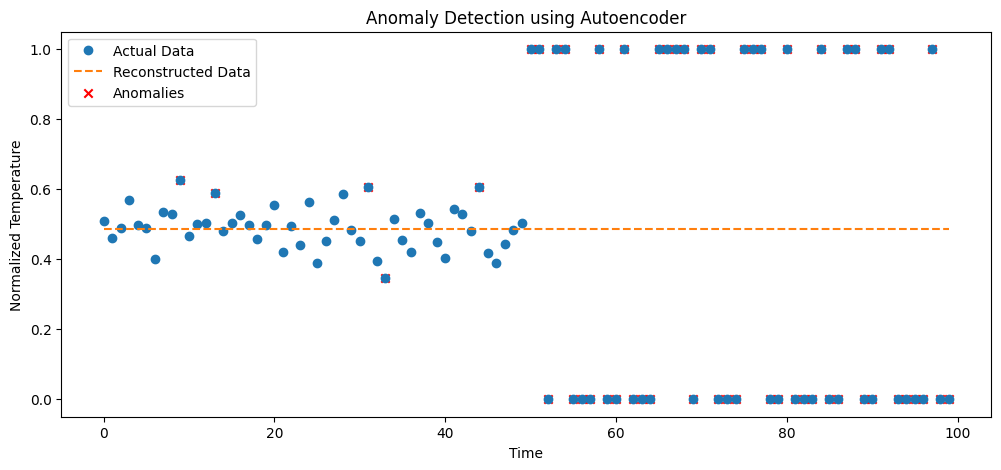

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

# Normalize data
scaler = MinMaxScaler()
df["Temperature_scaled"] = scaler.fit_transform(df[["Temperature"]])

# Split into training and testing sets
train_data = df["Temperature_scaled"][:900]  # Normal data for training
test_data = df["Temperature_scaled"][900:]  # Includes anomalies

# Convert data to NumPy arrays
train_data = np.array(train_data).reshape(-1, 1)
test_data = np.array(test_data).reshape(-1, 1)

# Define the autoencoder model
model = keras.Sequential([
    keras.layers.Dense(8, activation='relu', input_shape=(1,)),
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(train_data, train_data, epochs=50, batch_size=16, verbose=1)

# Get reconstructed values
reconstructed = model.predict(test_data)

# Compute reconstruction error
errors = np.abs(reconstructed - test_data)

# Define an anomaly threshold (e.g., 0.1)
threshold = 0.1
anomalies_detected = errors > threshold

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(test_data, label="Actual Data", marker='o', linestyle='')
plt.plot(reconstructed, label="Reconstructed Data", linestyle='dashed')
plt.scatter(np.where(anomalies_detected)[0], test_data[anomalies_detected], color='red', label="Anomalies", marker='x')
plt.legend()
plt.xlabel("Time")
plt.ylabel("Normalized Temperature")
plt.title("Anomaly Detection using Autoencoder")
plt.show()


Step 3: Convert the Model to TensorFlow Lite

We now convert the trained model to a TensorFlow Lite (TFLite) format for deployment on an IoT device.

In [ ]:
# Convert the model to TFLite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model
with open("anomaly_detector.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Model successfully converted to TensorFlow Lite format!")


Saved artifact at '/tmp/tmpvpeig8zg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_21')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139088836521296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139088755456912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139088755457680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139088755457104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139088755456336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139088745629264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139088745628688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139088745630032: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Model successfully converted to TensorFlow Lite format!


### STEP BY STEP

####  Step 1: Install Dependencies
First, we need TensorFlow and TensorFlow Lite. Run this in Google Colab:


In [ ]:
!pip install tensorflow numpy matplotlib

####   Step 2: Import Required Libraries

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


#### Step 3: Load & Visualize a Sample Dataset

We'll use MNIST (handwritten digits) as an example since it's lightweight, perfect for TinyML.

🎨 What’s happening?

We load MNIST dataset (28x28 grayscale images).

We normalize values (better for training).

We plot some digits to understand the data.


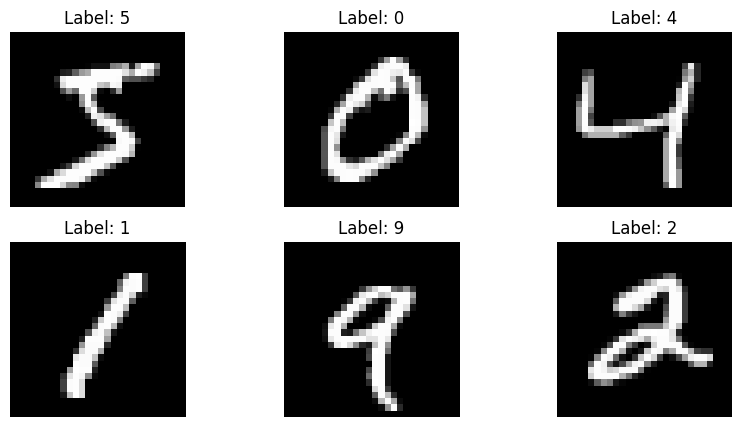

In [ ]:
# Load the MNIST dataset (handwritten digits)
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize data (scale pixel values between 0 and 1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Visualize some images
plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()


 ####  Step 4: Train a Small Neural Network

We'll train a simple CNN (Convolutional Neural Network) for digit classification.



🚀 What's happening?

Flatten: Converts 28x28 image into 1D.

Dense Layers: Fully connected layers for learning patterns.

Activation Functions:

* ReLU: Helps the model learn faster.

* Softmax: Converts outputs into probabilities.

* Adam Optimizer: Adaptive learning technique.

* Loss Function: Measures how well the model is performing.


In [ ]:
# Build a simple neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),  # Flatten 2D image to 1D
    tf.keras.layers.Dense(128, activation='relu'),  # Fully connected layer
    tf.keras.layers.Dense(10, activation='softmax')  # Output layer for 10 digits
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8787 - loss: 0.4292 - val_accuracy: 0.9622 - val_loss: 0.1295
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9657 - loss: 0.1169 - val_accuracy: 0.9703 - val_loss: 0.0938
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9775 - loss: 0.0762 - val_accuracy: 0.9743 - val_loss: 0.0827
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9831 - loss: 0.0562 - val_accuracy: 0.9743 - val_loss: 0.0772
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9863 - loss: 0.0437 - val_accuracy: 0.9771 - val_loss: 0.0753


####   Step 5: Convert Model to TensorFlow Lite

TinyML models must be small! We’ll convert it to a .tflite file.

📦 What’s happening?

TFLiteConverter shrinks the model for TinyML devices.

The model is saved as model.tflite.

In [ ]:
# Convert the model to TensorFlow Lite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model
with open("model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Model converted to TensorFlow Lite format!")

Saved artifact at '/tmp/tmpf9edzgs1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor_13')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139088836514960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139088836516496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139088836516880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139088836520528: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Model converted to TensorFlow Lite format!


####   Step 6: Load & Run Inference on TensorFlow Lite

Now, let's simulate how this model would run on a real TinyML device.

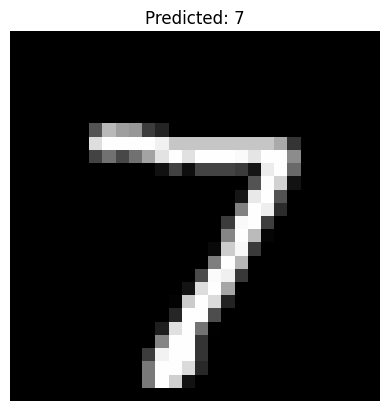

In [ ]:
# Load the TFLite model
interpreter = tf.lite.Interpreter(model_path="model.tflite")
interpreter.allocate_tensors()

# Get input/output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test inference on a single image
test_image = x_test[0].astype(np.float32).reshape(1, 28, 28)  # Reshape for model
interpreter.set_tensor(input_details[0]['index'], test_image)
interpreter.invoke()  # Run inference

# Get prediction
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_digit = np.argmax(output_data)

# Show results
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {predicted_digit}")
plt.axis('off')
plt.show()

🎯 What Did We Achieve?

✅ Trained a simple ML model (digit classification).

✅ Converted it to TensorFlow Lite (optimized for TinyML).

✅ Simulated inference (like running it on a microcontroller).



### One shot

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7635 - loss: 0.6883 - val_accuracy: 0.8453 - val_loss: 0.4360
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8577 - loss: 0.3934 - val_accuracy: 0.8496 - val_loss: 0.4175
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8701 - loss: 0.3518 - val_accuracy: 0.8590 - val_loss: 0.3952
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8792 - loss: 0.3285 - val_accuracy: 0.8605 - val_loss: 0.3870
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8876 - loss: 0.3064 - val_accuracy: 0.8728 - val_loss: 0.3692
Saved artifact at '/tmp/tmp77dm1ywq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139090685938384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  

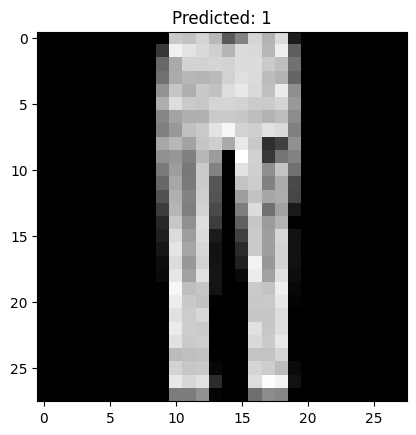

TinyML Model Prediction: 1


In [ ]:
# =========================================
# 🧪 Lab 3: Deep Dive into TinyML (Google Colab)
# =========================================

# ✅ Step 1: Install Dependencies
!pip install tensorflow numpy matplotlib

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ✅ Step 2: Load and Preprocess Data (Human Activity Recognition - HAR)
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to range [0,1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# ✅ Step 3: Build a TinyML Model (Lightweight Neural Network for HAR)
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ✅ Step 4: Train the Model
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# ✅ Step 5: Convert Model to TensorFlow Lite (TFLite)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TFLite model
with open("tinyml_model_fashion.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Model successfully converted to TFLite!")

# ✅ Step 6: Simulate Edge Deployment (Inference using TFLite)
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Pick a random test image
random_idx = np.random.randint(0, len(x_test))
test_image = x_test[random_idx].reshape(1, 28, 28).astype(np.float32)

# Run inference on TFLite model
interpreter.set_tensor(input_details[0]['index'], test_image)
interpreter.invoke()
predictions = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(predictions)

# ✅ Step 7: Display the Result
plt.imshow(x_test[random_idx], cmap='gray')
plt.title(f"Predicted: {predicted_label}")
plt.show()
print(f"TinyML Model Prediction: {predicted_label}")

# ✅ Step 8: Next Steps for Deployment (Optional)
# This TFLite model can now be deployed on microcontrollers like Arduino Nano 33 BLE Sense!
